# Benchmark di Controllo AID: Reiezione di Pasti Non Annunciati

Questo notebook implementa e confronta due architetture di controllo a circuito chiuso su ambiente di simulazione *in silico* basato su `simglucose` (modello metabolico UVA/Padova):
1. **PID Baseline Convenzionale**: regolatore proporzionale-integrale-derivativo accordato sul target euglicemico ($110\text{ mg/dL}$).
2. **PID con Vincolo su IOB e Modulo PLGS**: regolatore con saturazione dinamica basata sulla stima in tempo reale dell'insulina attiva ($IOB(t)$) e sospensione preventiva dell'infusione (*Predictive Low-Glucose Suspend*).

### Parametri dello Scenario Sperimentale
- **Paziente virtuale**: `adult#001`
- **Durata temporale**: $16\text{ ore}$ nominali (dalle ore 08:00 alle 00:00)
- **Frequenza di campionamento**: $\Delta t = 3\text{ minuti}$ (`env.sample_time = 3.0`), pari a $320\text{ passi}$
- **Disturbo esogeno**: pasto non annunciato da $60\text{ g}$ di carboidrati alle ore 12:00 ($t = 240\text{ min}$)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from simglucose.simulation.env import T1DSimEnv
from simglucose.actuator.pump import InsulinPump
from simglucose.sensor.cgm import CGMSensor
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.simulation.scenario import CustomScenario
from simglucose.controller.base import Controller, Action

print("Librerie importate con successo.")

/Users/marti/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Librerie importate con successo.


## 1. Definizione degli Algoritmi di Controllo

### Formulazione Matematica a Tempo Discreto ($dt = 3\text{ min}$)
A ogni passo di campionamento $\Delta t = 3\text{ min}$, l'errore di regolazione è definito come $e(k) = G(k) - G_{target}$.
- L'azione integrale è integrata numericamente: $I(k) = I(k-1) + e(k) \cdot \Delta t$.
- L'azione derivativa quantifica la pendenza al minuto: $D(k) = \frac{G(k) - G(k-1)}{\Delta t}$.
- L'osservatore IOB integra l'insulina eccedente nei due compartimenti sottocutanei a costante di tempo $\tau_s = 50\text{ min}$.

In [2]:
class StandardPIDController(Controller):
    def __init__(self, target=110.0, kp=0.0006, ki=0.000015, kd=0.004, basal_rate=0.021, dt=3.0):
        self.target = target
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.basal_rate = basal_rate
        self.dt = dt
        self.integral_error = 0.0
        self.prev_cgm = None

    def policy(self, observation, reward, done, **info):
        cgm = observation.CGM
        error = cgm - self.target
        
        self.integral_error += error * self.dt
        self.integral_error = float(np.clip(self.integral_error, -3000.0, 10000.0))
        
        d_cgm_dt = 0.0 if self.prev_cgm is None else (cgm - self.prev_cgm) / self.dt
        self.prev_cgm = cgm
        
        correction = (self.kp * error) + (self.ki * self.integral_error) + (self.kd * d_cgm_dt)
        u = max(0.0, min(self.basal_rate + correction, 0.25))
        return Action(basal=u, bolus=0.0)

    def reset(self):
        self.integral_error = 0.0
        self.prev_cgm = None


class IOBConstrainedController(Controller):
    def __init__(self, target=110.0, kp=0.0006, ki=0.000015, kd=0.004, basal_rate=0.021, 
                 tau_s=50.0, iob_cap=2.2, plgs_threshold=90.0, dt=3.0):
        self.target = target
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.basal_rate = basal_rate
        self.tau_s = tau_s
        self.iob_cap = iob_cap
        self.plgs_threshold = plgs_threshold
        self.dt = dt
        
        self.integral_error = 0.0
        self.prev_cgm = None
        self.s1 = 0.0
        self.s2 = 0.0
        self.current_iob = 0.0

    def policy(self, observation, reward, done, **info):
        cgm = observation.CGM
        error = cgm - self.target
        
        self.current_iob = (self.s1 + self.s2) / 60.0
        d_cgm_dt = 0.0 if self.prev_cgm is None else (cgm - self.prev_cgm) / self.dt
        cgm_projected = cgm + (d_cgm_dt * 20.0)
        
        if cgm > self.target:
            self.integral_error += error * self.dt
        else:
            self.integral_error = max(0.0, self.integral_error - (abs(error) * self.dt * 0.5))
        self.integral_error = float(np.clip(self.integral_error, -1000.0, 6000.0))
        
        correction = (self.kp * error) + (self.ki * self.integral_error) + (self.kd * d_cgm_dt)
        u = self.basal_rate + correction
        
        # Vincolo di saturazione IOB contro l'insulin stacking
        if self.current_iob > self.iob_cap and u > self.basal_rate:
            u = self.basal_rate
            
        # Modulo di sospensione predittiva PLGS
        if cgm_projected < self.plgs_threshold or cgm < 75.0:
            u = 0.0
            
        u = max(0.0, min(u, 0.25))
        
        u_excess = max(0.0, u - self.basal_rate)
        ds1 = (u_excess - (self.s1 / self.tau_s)) * self.dt
        ds2 = ((self.s1 / self.tau_s) - (self.s2 / self.tau_s)) * self.dt
        self.s1 += ds1
        self.s2 += ds2
        self.prev_cgm = cgm
        
        return Action(basal=u, bolus=0.0)

    def reset(self):
        self.integral_error = 0.0
        self.prev_cgm = None
        self.s1 = 0.0
        self.s2 = 0.0
        self.current_iob = 0.0

## 2. Esecuzione del Protocollo di Simulazione (16 Ore)

In [3]:
def run_simulation(controller_class, patient_name='adult#001', meal_cho=60.0):
    start_time = datetime(2026, 1, 1, 8, 0, 0)
    sim_hours = 16
    meal_scenario = [(12.0, meal_cho)]
    
    patient = T1DPatient.withName(patient_name)
    sensor = CGMSensor.withName('Dexcom', seed=1)
    pump = InsulinPump.withName('Insulet')
    scenario = CustomScenario(start_time=start_time, scenario=meal_scenario)
    env = T1DSimEnv(patient, sensor, pump, scenario)
    
    dt = env.sample_time
    total_steps = int(sim_hours * 60 / dt)
    
    bw = patient._params['BW']
    u2ss = patient._params['u2ss']
    basal_nominal = (u2ss * bw) / 6000.0
    
    controller = controller_class(basal_rate=basal_nominal, dt=dt)
    
    time_list, cgm_list, bg_list, insulin_list, iob_list = [], [], [], [], []
    obs, reward, done, info = env.reset()
    controller.reset()
    
    for step in range(total_steps):
        current_t = start_time + timedelta(minutes=step * dt)
        action = controller.policy(obs, reward, done, **info)
        
        time_list.append(current_t)
        cgm_list.append(obs.CGM)
        bg_list.append(env.patient.state[0])
        insulin_list.append(action.basal * 60.0)
        iob_list.append(getattr(controller, 'current_iob', 0.0))
        
        obs, reward, done, info = env.step(action)
        if done:
            break
            
    return pd.DataFrame({
        'Time': time_list,
        'CGM': cgm_list,
        'BG': bg_list,
        'Insulin_Uh': insulin_list,
        'IOB': iob_list
    })

print("Esecuzione benchmark nominale su adult#001 (60g CHO)...")
df_pid = run_simulation(StandardPIDController, 'adult#001', 60.0)
df_iob = run_simulation(IOBConstrainedController, 'adult#001', 60.0)
print("Simulazioni completate.")

Esecuzione benchmark nominale su adult#001 (60g CHO)...


Simulazioni completate.


## 3. Calcolo delle Metriche Cliniche di Consenso

In [4]:
def compute_metrics(df, label):
    cgm = df['CGM'].values
    n = len(cgm)
    
    tir = np.sum((cgm >= 70.0) & (cgm <= 180.0)) / n * 100.0
    tar = np.sum(cgm > 180.0) / n * 100.0
    tbr = np.sum(cgm < 70.0) / n * 100.0
    
    mask_late = (df['Time'] >= datetime(2026, 1, 1, 15, 0, 0)) & (df['Time'] <= datetime(2026, 1, 1, 18, 0, 0))
    cgm_late = df.loc[mask_late, 'CGM'].values
    tbr_late = np.sum(cgm_late < 70.0) / len(cgm_late) * 100.0 if len(cgm_late) > 0 else 0.0
    
    return {
        'Controllore': label,
        'TIR [%]': round(tir, 2),
        'TAR [%]': round(tar, 2),
        'TBR [%]': round(tbr, 2),
        'TBR Tardivo (3-6h) [%]': round(tbr_late, 2),
        'Picco [mg/dL]': round(float(np.max(cgm)), 1),
        'Nadir [mg/dL]': round(float(np.min(cgm)), 1)
    }

df_results = pd.DataFrame([
    compute_metrics(df_pid, 'PID Baseline'),
    compute_metrics(df_iob, 'PID + Vincolo IOB + PLGS')
])
display(df_results)

,Controllore,TIR [%],TAR [%],TBR [%],TBR Tardivo (3-6h) [%],Picco [mg/dL],Nadir [mg/dL]
0,PID Baseline,54.69,11.88,33.44,100.00,214.3,39.0
1,PID + Vincolo IOB + PLGS,62.81,14.37,22.81,81.97,204.8,45.3


## 4. Visualizzazione a 3 Pannelli Sincronizzata

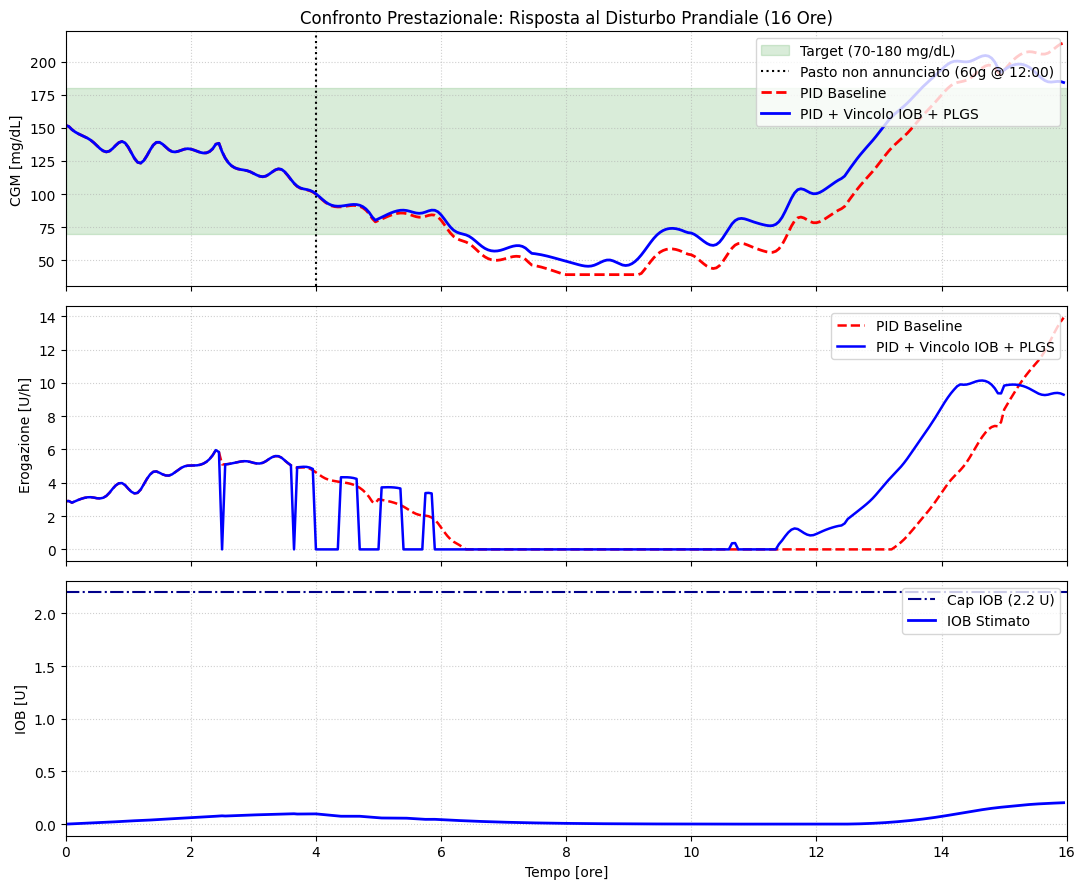

Grafico esportato in grafico_benchmark_baseline.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
t_hours = [(t - df_pid['Time'].iloc[0]).total_seconds() / 3600.0 for t in df_pid['Time']]

# 1. Glicemia
axes[0].axhspan(70, 180, color='green', alpha=0.15, label='Target (70-180 mg/dL)')
axes[0].axvline(4.0, color='black', linestyle=':', label='Pasto non annunciato (60g @ 12:00)')
axes[0].plot(t_hours, df_pid['CGM'], 'r--', linewidth=2, label='PID Baseline')
axes[0].plot(t_hours, df_iob['CGM'], 'b-', linewidth=2, label='PID + Vincolo IOB + PLGS')
axes[0].set_ylabel('CGM [mg/dL]')
axes[0].set_title('Confronto Prestazionale: Risposta al Disturbo Prandiale (16 Ore)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Infusione
axes[1].plot(t_hours, df_pid['Insulin_Uh'], 'r--', linewidth=1.8, label='PID Baseline')
axes[1].plot(t_hours, df_iob['Insulin_Uh'], 'b-', linewidth=1.8, label='PID + Vincolo IOB + PLGS')
axes[1].set_ylabel('Erogazione [U/h]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

# 3. IOB
axes[2].axhline(2.2, color='darkblue', linestyle='-.', label='Cap IOB (2.2 U)')
axes[2].plot(t_hours, df_iob['IOB'], 'b-', linewidth=2, label='IOB Stimato')
axes[2].set_ylabel('IOB [U]')
axes[2].set_xlabel('Tempo [ore]')
axes[2].set_xlim([0, 16])
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('grafico_benchmark_baseline.png', dpi=300)
plt.show()
print("Grafico esportato in grafico_benchmark_baseline.png")